In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from pyomo.environ import *

In [27]:
# -----------------------
# 1. DATA
# -----------------------
prices = pd.read_excel('Prices.xlsx', sheet_name='PRICE_ELECTRIC')
p_elec = prices['NP15 ($/MWh)'].tolist()

natural_gas = pd.read_excel('Prices.xlsx', sheet_name='PRICE_GAS')
ng_daily = natural_gas['PG&E Citygate ($/MMBtu)'].tolist()
p_gas = [x for x in ng_daily for _ in range(24)]

co2_cost = 15  # $/MWh

T = range(len(p_elec))
C = ['C1', 'C2', 'C3', 'C4', 'C5']

In [ ]:
# Parameters (same logic as AMPL model)
params = {
    'C1': {'min': 0,   'max': 0,   'hr': 0,     'vom': 0},
    'C2': {'min': 57,  'max': 190, 'hr': 9.1,   'vom': 5},
    'C3': {'min': 114, 'max': 380, 'hr': 9.1,   'vom': 10},
    'C4': {'min': 150, 'max': 340, 'hr': 6.5,   'vom': 2.5},
    'C5': {'min': 312, 'max': 610, 'hr': 6.3,   'vom': 2}
}

min_up = {'C1': 0, 'C2': 1, 'C3': 1, 'C4': 2, 'C5': 3}
min_down = {'C1': 0, 'C2': 1, 'C3': 1, 'C4': 2, 'C5': 3}

# Initial conditions
U0 = {'C1': 1, 'C2': 0, 'C3': 0, 'C4': 0, 'C5': 0}
P0 = 0

# Possible transitions between configurations at every unit of time
transitions = [
    ('C1','C1'), ('C2','C2'), ('C3','C3'),
    ('C4','C4'), ('C5','C5'),
    ('C1', 'C2'), ('C1', 'C3'), ('C1', 'C4'),
    ('C2', 'C1'), ('C2', 'C3'), ('C2', 'C4'),
    ('C3', 'C1'), ('C3', 'C2'),
    ('C4', 'C1'), ('C4', 'C2'), ('C4', 'C5'),
    ('C5', 'C1'), ('C5', 'C4')
]

# Startup fuel (MMBtu)
startup_fuel = {
    ('C1', 'C2'): 220, ('C1', 'C3'): 440, ('C1', 'C4'): 850,
    ('C2', 'C1'): 0, ('C2', 'C3'): 220, ('C2', 'C4'): 630,
    ('C3', 'C1'): 0, ('C3', 'C2'): 0,
    ('C4', 'C1'): 0, ('C4', 'C2'): 0, ('C4', 'C5'): 220,
    ('C5', 'C1'): 0, ('C5', 'C4'): 0
    }

# Startup costs (non-fuel)
startup_costs = {
    ('C1', 'C2'): 7250, ('C1', 'C3'): 14500, ('C1', 'C4'): 16500,
    ('C2', 'C1'): 0, ('C2', 'C3'): 7250, ('C2', 'C4'): 9250,
    ('C3', 'C1'): 0, ('C3', 'C2'): 0,
    ('C4', 'C1'): 0, ('C4', 'C2'): 0, ('C4', 'C5'): 7250,
    ('C5', 'C1'): 0, ('C5', 'C4'): 0
    }

In [29]:
# -----------------------
# 2. MODEL
# -----------------------
model = ConcreteModel()

model.T = Set(initialize=T)
model.C = Set(initialize=C)
model.TRANS = Set(initialize=transitions, dimen=2)

In [30]:
# -----------------------
# 3. VARIABLES
# -----------------------
model.U = Var(model.T, model.C, domain=Binary)
model.P = Var(model.T, model.C, domain=NonNegativeReals)
model.z = Var(model.T, model.TRANS, domain=Binary)

In [31]:
# -----------------------
# 4. OBJECTIVE
# -----------------------
def obj_rule(model):

    revenue = sum(
        p_elec[t] * model.P[t,c]
        for t in model.T for c in model.C
    )

    op_cost = sum(
        model.P[t,c] * (params[c]['hr'] * p_gas[t] + params[c]['vom'] + co2_cost)
        for t in model.T for c in model.C
    )

    startup = sum(
        model.z[t,(c1,c2)] * (startup_costs.get((c1,c2),0) + startup_fuel.get((c1,c2),0) * p_gas[t])
        for t in model.T for (c1,c2) in model.TRANS
    )

    return revenue - op_cost - startup

model.Profit = Objective(rule=obj_rule, sense=maximize)

In [32]:
# -----------------------
# 5. CONSTRAINTS
# -----------------------

# One configuration
def one_config_rule(model, t):
    return sum(model.U[t,c] for c in model.C) == 1
model.OneConfig = Constraint(model.T, rule=one_config_rule)

# Power bounds
def p_min_rule(model, t, c):
    return model.P[t,c] >= params[c]['min'] * model.U[t,c]
model.PMin = Constraint(model.T, model.C, rule=p_min_rule)

def p_max_rule(model, t, c):
    return model.P[t,c] <= params[c]['max'] * model.U[t,c]
model.PMax = Constraint(model.T, model.C, rule=p_max_rule)

# Transition logic (flow conservation)
def trans_in_rule(model, t, c):
    if t == 0:
        return model.U[t,c] == U0[c]
    return model.U[t,c] == sum(
        model.z[t,(c_prev,c)]
        for (c_prev,c2) in model.TRANS if c2 == c
    )
model.TransIn = Constraint(model.T, model.C, rule=trans_in_rule)

def trans_out_rule(model, t, c):
    if t == 0:
        return Constraint.Skip
    return model.U[t-1,c] == sum(
        model.z[t,(c,c_next)]
        for (c1,c_next) in model.TRANS if c1 == c
    )
model.TransOut = Constraint(model.T, model.C, rule=trans_out_rule)

# Enforce 1x1 -> 2x1 path
def c5_rule(model, t):
    if t == 0:
        return Constraint.Skip
    return model.U[t,'C5'] <= model.U[t-1,'C4'] + model.U[t-1,'C5']
model.C5Path = Constraint(model.T, rule=c5_rule)

# Minimum up time
def min_up_rule(model, t, c):
    m_up = min_up[c]
    if t < m_up: return Constraint.Skip
    # If we transitioned into 'c' from elsewhere at time 's', we must stay in 'c' through 't'
    return model.U[t, c] >= sum(model.z[s, c_prev, c] 
                               for s in range(t - m_up + 1, t + 1)
                               for (c_prev, c_to) in model.TRANS if c_to == c and c_prev != c)
model.MinUp = Constraint(model.T, model.C, rule=min_up_rule)

# minimum down time
def min_down_rule(model, t, c):
    m_down = min_down[c]
    if t < m_down: return Constraint.Skip
    # If we transitioned out of 'c' at time 's', we must stay out of 'c' through 't'
    return (1 - model.U[t, c]) >= sum(model.z[s, c, c_next] 
                                    for s in range(t - m_down + 1, t + 1)
                                    for (c_from, c_next) in model.TRANS if c_from == c and c_next != c)
model.MinDown = Constraint(model.T, model.C, rule=min_down_rule)

In [33]:
# -----------------------
# 6. SOLVE
# -----------------------
solver = SolverFactory('appsi_highs')
results = solver.solve(model)

print(f"Total Profit: ${value(model.Profit):,.2f}")

Total Profit: $114,441.67


In [34]:
# -----------------------
# 7. EXPORT RESULTS
# -----------------------
import csv
from datetime import datetime, timedelta

start_date = datetime(2024,1,1)
rows = []

for t in model.T:
    active_c = max(model.C, key=lambda c: value(model.U[t,c]))
    mw = sum(value(model.P[t,c]) for c in model.C)

    dt = start_date + timedelta(hours=t)

    rows.append([
        dt.strftime("%Y-%m-%d"),
        dt.hour + 1,
        p_elec[t],
        p_gas[t],
        active_c,
        mw
    ])

with open("CCGT_CAISO.csv","w",newline="") as f:
    writer = csv.writer(f)
    writer.writerow([
        "OPERATING_DATE","HOUR_ENDING",
        "PRICE_ELECTRIC","PRICE_GAS",
        "CONFIGURATION_ACTIVE","MW_GENERATION"
    ])
    writer.writerows(rows)

In [35]:
df = pd.read_csv("CCGT_CAISO.csv")
print(df.head(12))

   OPERATING_DATE  HOUR_ENDING  PRICE_ELECTRIC  PRICE_GAS  \
0      2024-01-01            1           45.04       7.05   
1      2024-01-01            2           43.63       7.05   
2      2024-01-01            3           43.43       7.05   
3      2024-01-01            4           43.42       7.05   
4      2024-01-01            5           46.30       7.05   
5      2024-01-01            6           55.50       7.05   
6      2024-01-01            7           76.70       7.05   
7      2024-01-01            8           77.29       7.05   
8      2024-01-01            9           51.19       7.05   
9      2024-01-01           10           46.89       7.05   
10     2024-01-01           11           43.54       7.05   
11     2024-01-01           12           37.18       7.05   

   CONFIGURATION_ACTIVE  MW_GENERATION  
0                    C1            0.0  
1                    C1            0.0  
2                    C1            0.0  
3                    C1            0.0  
4

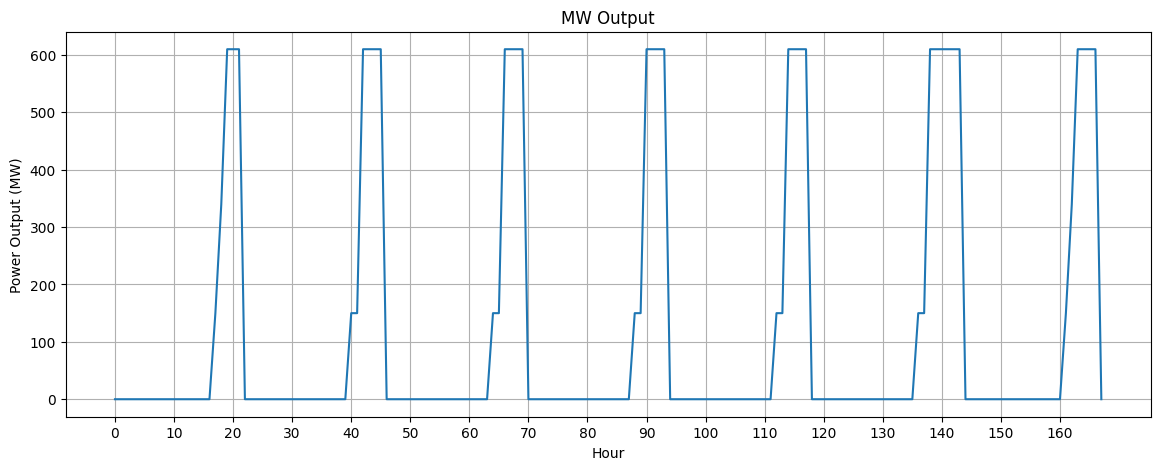

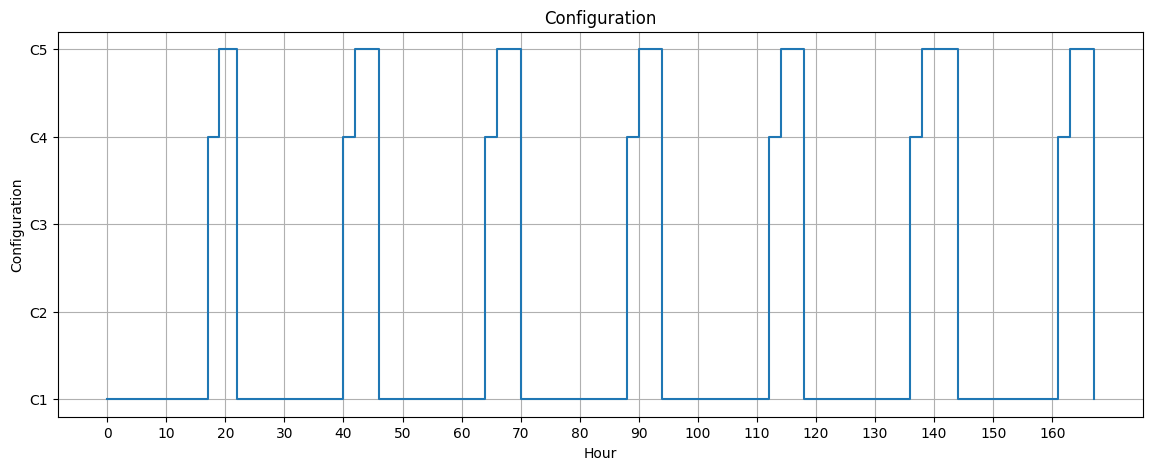

In [36]:
# -----------------------
# 8. PLOTS
# -----------------------
mw_series = [sum(value(model.P[t,c]) for c in model.C) for t in model.T]

plt.figure(figsize=(14,5))
plt.plot(mw_series)
plt.xlabel("Hour")
plt.ylabel("Power Output (MW)")
plt.xticks(range(0, len(mw_series), 10))
plt.title("MW Output")
plt.grid()
plt.show()

config_series = [
    max(model.C, key=lambda c: value(model.U[t,c]))
    for t in model.T
]

config_map = {c:i+1 for i,c in enumerate(C)}
config_numeric = [config_map[c] for c in config_series]

plt.figure(figsize=(14,5))
plt.step(range(len(config_numeric)), config_numeric, where='post')
plt.xlabel("Hour")
plt.ylabel("Configuration")
plt.xticks(range(0, len(mw_series), 10))
plt.yticks(list(config_map.values()), list(config_map.keys()))
plt.title("Configuration")
plt.grid()
plt.show()

In [39]:
# -----------------------
# 9. METRICS
# -----------------------
revenue = sum(
    p_elec[t]*sum(value(model.P[t,c]) for c in model.C)
    for t in model.T
)

fuel_cost = sum(
    value(model.P[t,c])*params[c]['hr']*p_gas[t]
    for t in model.T for c in model.C if c!='C1'
)

vom_cost = sum(
    value(model.P[t,c])*params[c]['vom']
    for t in model.T for c in model.C if c!='C1'
)

co2_total = sum(
    value(model.P[t,c])*co2_cost
    for t in model.T for c in model.C if c!='C1'
)

startup_total = sum(
    value(model.z[t,(c1,c2)]) * (
        startup_costs.get((c1,c2),0) +
        startup_fuel.get((c1,c2),0)*p_gas[t]
    )
    for t in model.T for (c1,c2) in model.TRANS
)

total_cost = fuel_cost + vom_cost + co2_total + startup_total

capacity = params['C5']['max']
total_mwh = sum(sum(value(model.P[t,c]) for c in model.C) for t in model.T)

capacity_factor = total_mwh / (capacity * len(model.T))
gross_margin = (revenue - total_cost)/(capacity*1000)

cold_starts = sum(
    value(model.z[t, 'C1', c])
    for t in model.T 
    for c in model.C 
    if c != 'C1' and ('C1', c) in transitions
)

total_transitions = sum(
    value(model.z[t, c1, c2])
    for t in model.T 
    for (c1, c2) in model.TRANS 
    if c1 != c2
)

print(f"Revenue: ${revenue:,.0f}")
print(f"Total Cost: ${total_cost:,.0f}")
print(f"Fuel: ${fuel_cost:,.0f}")
print(f"Startup: ${startup_total:,.0f}")
print(f"Capacity Factor: {capacity_factor*100:.2f}%")
print(f"Gross Margin: ${gross_margin:.4f}/kW")
print(f"Cold starts: {cold_starts:.0f}")
print(f"Total transitions: {total_transitions:.0f}")

Revenue: $1,586,806
Total Cost: $1,472,365
Fuel: $908,795
Startup: $219,440
Capacity Factor: 19.68%
Gross Margin: $0.1876/kW
Cold starts: 7
Total transitions: 21
